In [1]:
##-------------------------------------------
## Libraries & Paths

suppressMessages(library(magrittr))
suppressMessages(library(dplyr))
suppressMessages(library(GSVA))
suppressMessages(library(GSEABase))
suppressMessages(library(org.Hs.eg.db))
suppressMessages(library(AnnotationDbi))
suppressMessages(library(limma))
suppressMessages(library(tidyverse))
suppressMessages(library(matrixStats))
suppressMessages(library(DESeq2))
suppressMessages(library(edgeR))
source("/workdir/cjl332/cfrna_template/theme_ggplot_cfrna.R")
gene.list = read.delim("/workdir/cfrna/references/human/hg38/gencode.biotype.name.key.tsv")

Warning message:
“package ‘magrittr’ was built under R version 4.2.3”
Warning message:
“package ‘dplyr’ was built under R version 4.2.3”
Warning message:
“package ‘Biobase’ was built under R version 4.2.3”
Warning message:
“package ‘IRanges’ was built under R version 4.2.3”
Warning message:
“package ‘tibble’ was built under R version 4.2.3”
Warning message:
“package ‘tidyr’ was built under R version 4.2.3”
Warning message:
“package ‘purrr’ was built under R version 4.2.3”
Warning message:
“package ‘stringr’ was built under R version 4.2.3”
Warning message:
“package ‘forcats’ was built under R version 4.2.3”
Warning message:
“package ‘lubridate’ was built under R version 4.2.3”
Warning message:
“package ‘DESeq2’ was built under R version 4.2.3”
Warning message:
“package ‘GenomicRanges’ was built under R version 4.2.3”
Warning message:
“package ‘GenomeInfoDb’ was built under R version 4.2.3”


In [2]:
# Read in data
KD_gpt = read.csv("/workdir/adb258/ai_paper/data/KD_gpt_genes.csv", row.names = 1, header = FALSE)
KD_claude = read.csv("/workdir/adb258/ai_paper/data/KD_claude_genes.csv", row.names = 1, header = FALSE)
KD_gemini = read.csv("/workdir/adb258/ai_paper/data/KD_gemini_genes.csv", row.names = 1, header = FALSE)
TB_gpt = read.csv("/workdir/adb258/ai_paper/data/TB_gpt_genes.csv", row.names = 1, header = FALSE)
TB_claude = read.csv("/workdir/adb258/ai_paper/data/TB_claude_genes.csv", row.names = 1, header = FALSE)
TB_gemini = read.csv("/workdir/adb258/ai_paper/data/TB_gemini_genes.csv", row.names = 1, header = FALSE)
MECFS_gpt = read.csv("/workdir/adb258/ai_paper/data/MECFS_gpt_genes.csv", row.names = 1, header = FALSE)
MECFS_claude = read.csv("/workdir/adb258/ai_paper/data/MECFS_claude_genes.csv", row.names = 1, header = FALSE)
MECFS_gemini = read.csv("/workdir/adb258/ai_paper/data/MECFS_gemini_genes.csv", row.names = 1, header = FALSE)

In [3]:
##-------------------------------------------
# Load pathways

### H
hallmark_pathways <- getGmt("/workdir/cjl332/ssGSEA/NEW_2024.07.10/gene_sets/h.all.v2023.2.Hs.symbols.gmt.txt")

### C2 - REACTOME
c2_pathways <- getGmt("/workdir/cjl332/ssGSEA/NEW_2024.07.10/gene_sets/c2.all.v2023.2.Hs.symbols.gmt.txt")
reactome_pathways <- c2_pathways[grepl("^REACTOME", names(c2_pathways)),]

### C5 - BP & HPO
c5_pathways <- getGmt("/workdir/cjl332/ssGSEA/NEW_2024.07.10/gene_sets/c5.all.v2023.2.Hs.symbols.gmt.txt")
BP_pathways <- c5_pathways[grepl("^GOBP", names(c5_pathways)),]

### C7
c7_pathways <- getGmt("/workdir/cjl332/ssGSEA/NEW_2024.07.10/gene_sets/c7.all.v2023.2.Hs.symbols.gmt.txt")

### COMBINE
all_pathways <- c(reactome_pathways, BP_pathways, hallmark_pathways)
all_pathways <- GeneSetCollection(all_pathways)

#-------------------------------------------
pathway_genes <- lapply(all_pathways, function(gs) {
  genes <- geneIds(gs)
    return(genes)
})

# Ensure that pathway names are correctly set
pathway_names <- names(all_pathways)

# Create a dataframe with pathway names and associated genes
pathway_genes_df <- data.frame(
  pathway = pathway_names,
  genes = sapply(pathway_genes, function(genes) paste(genes, collapse = ", ")),
  stringsAsFactors = FALSE
)

In [4]:
options(matrixStats.useNames.NA = "deprecated")

In [5]:
##-------------------------------------------
## Run analysis & save output

# Perform ssGSEA using GSVA
# ssgsea_results <- gsva(gene_count_matrix, all_pathways, method = "ssgsea", ssgsea.norm = FALSE)

kd_gpt_mat = as.matrix(KD_gpt)
tb_gpt_mat = as.matrix(TB_gpt)
mecfs_gpt_mat = as.matrix(MECFS_gpt)

ssgsea_kd_gpt <- data.frame(gsva(kd_gpt_mat, all_pathways, method = "ssgsea", ssgsea.norm = FALSE,
                        tau = 0.75, parallel.sz = 10, min.sz=10))

ssgsea_tb_gpt <- data.frame(gsva(tb_gpt_mat, all_pathways, method = "ssgsea", ssgsea.norm = FALSE,
                        tau = 0.75, parallel.sz = 10, min.sz=10))

ssgsea_mecfs_gpt <- data.frame(gsva(mecfs_gpt_mat, all_pathways, method = "ssgsea", ssgsea.norm = FALSE,
                        tau = 0.75, parallel.sz = 10, min.sz=10))

Warning message:
“[matrixStats (>= 1.2.0)] useNames = NA is deprecated. Instead, specify either useNames = TRUE or useNames = FALSE. See also ?matrixStats::matrixStats.options”
Warning message in .filterFeatures(expr, method):
“1274 genes with constant expression values throuhgout the samples.”


Setting parallel calculations through a MulticoreParam back-end
with workers=10 and tasks=100.
Estimating ssGSEA scores for 2209 gene sets.
[1] "Calculating ranks..."


Warning message:
“[matrixStats (>= 1.2.0)] useNames = NA is deprecated. Instead, specify either useNames = TRUE or useNames = FALSE. See also ?matrixStats::matrixStats.options”


[1] "Calculating absolute values from ranks..."
  |======================================================================| 100%



Warning message:
“[matrixStats (>= 1.2.0)] useNames = NA is deprecated. Instead, specify either useNames = TRUE or useNames = FALSE. See also ?matrixStats::matrixStats.options”
Warning message in .filterFeatures(expr, method):
“1259 genes with constant expression values throuhgout the samples.”


...

[1] "Calculating absolute values from ranks..."
  |======================================================================| 100%



Warning message:
“[matrixStats (>= 1.2.0)] useNames = NA is deprecated. Instead, specify either useNames = TRUE or useNames = FALSE. See also ?matrixStats::matrixStats.options”
Warning message in .filterFeatures(expr, method):
“4122 genes with constant expression values throuhgout the samples.”


Setting parallel calculations through a MulticoreParam back-end
with workers=10 and tasks=100.
Estimating ssGSEA scores for 2699 gene sets.
[1] "Calculating ranks..."


Warning message:
“[matrixStats (>= 1.2.0)] useNames = NA is deprecated. Instead, specify either useNames = TRUE or useNames = FALSE. See also ?matrixStats::matrixStats.options”


[1] "Calculating absolute values from ranks..."
  |======================================================================| 100%



In [15]:
# Function to add Z-score and return top 10 by absolute Z
prepare_top10 <- function(df, title) {
  df <- df %>%
    rownames_to_column("Pathway") %>%
    mutate(Z = (V2 - mean(V2)) / sd(V2)) %>%
    arrange(desc(Z)) %>%
    slice_head(n = 10)
}

In [7]:
options(repr.plot.height = 4, repr.plot.width = 12)

 ggplot(p1, aes(x = reorder(Pathway, Z), y = Z)) +
   geom_bar(stat = "identity", fill = "#00A67E") +
   coord_flip() +  # Horizontal bars
   labs(x = NULL, y = "Enrichment Z-score", title = "KD/MIS-C") +
   theme_cfrna_slides() +
   theme(legend.position = "none", plot.title = element_text(hjust = 0.5))

 ggplot(p2, aes(x = reorder(Pathway, Z), y = Z)) +
   geom_bar(stat = "identity", fill = "#00A67E") +
   coord_flip() +  # Horizontal bars
   labs(x = NULL, y = "Enrichment Z-score", title = "TB") +
   theme_cfrna_slides() +
   theme(legend.position = "none", plot.title = element_text(hjust = 0.5))
 ggplot(p3, aes(x = reorder(Pathway, Z), y = Z)) +
   geom_bar(stat = "identity", fill = "#00A67E") +
   coord_flip() +  # Horizontal bars
   labs(x = NULL, y = "Enrichment Z-score", title = "MECFS") +
   theme_cfrna_slides() +
   theme(legend.position = "none", plot.title = element_text(hjust = 0.5))

ERROR: Error in ggplot(p1, aes(x = reorder(Pathway, Z), y = Z)): object 'p1' not found


In [8]:
##-------------------------------------------
## Run analysis & save output

# Perform ssGSEA using GSVA
# ssgsea_results <- gsva(gene_count_matrix, all_pathways, method = "ssgsea", ssgsea.norm = FALSE)

kd_gemini_mat = as.matrix(KD_gemini)
tb_gemini_mat = as.matrix(TB_gemini)
mecfs_gemini_mat = as.matrix(MECFS_gemini)

ssgsea_kd_gemini <- data.frame(gsva(kd_gemini_mat, all_pathways, method = "ssgsea", ssgsea.norm = FALSE,
                        tau = 0.75, parallel.sz = 10, min.sz=10))

ssgsea_tb_gemini <- data.frame(gsva(tb_gemini_mat, all_pathways, method = "ssgsea", ssgsea.norm = FALSE,
                        tau = 0.75, parallel.sz = 10, min.sz=10))

ssgsea_mecfs_gemini <- data.frame(gsva(mecfs_gemini_mat, all_pathways, method = "ssgsea", ssgsea.norm = FALSE,
                        tau = 0.75, parallel.sz = 10, min.sz=10))

Warning message:
“[matrixStats (>= 1.2.0)] useNames = NA is deprecated. Instead, specify either useNames = TRUE or useNames = FALSE. See also ?matrixStats::matrixStats.options”
Warning message in .filterFeatures(expr, method):
“939 genes with constant expression values throuhgout the samples.”


Setting parallel calculations through a MulticoreParam back-end
with workers=10 and tasks=100.
Estimating ssGSEA scores for 2264 gene sets.
[1] "Calculating ranks..."


Warning message:
“[matrixStats (>= 1.2.0)] useNames = NA is deprecated. Instead, specify either useNames = TRUE or useNames = FALSE. See also ?matrixStats::matrixStats.options”


[1] "Calculating absolute values from ranks..."
  |======================================================================| 100%



Warning message:
“[matrixStats (>= 1.2.0)] useNames = NA is deprecated. Instead, specify either useNames = TRUE or useNames = FALSE. See also ?matrixStats::matrixStats.options”
Warning message in .filterFeatures(expr, method):
“1383 genes with constant expression values throuhgout the samples.”


...

[1] "Calculating absolute values from ranks..."
  |======================================================================| 100%



Warning message:
“[matrixStats (>= 1.2.0)] useNames = NA is deprecated. Instead, specify either useNames = TRUE or useNames = FALSE. See also ?matrixStats::matrixStats.options”
Warning message in .filterFeatures(expr, method):
“1417 genes with constant expression values throuhgout the samples.”


Setting parallel calculations through a MulticoreParam back-end
with workers=10 and tasks=100.
Estimating ssGSEA scores for 2312 gene sets.
[1] "Calculating ranks..."


Warning message:
“[matrixStats (>= 1.2.0)] useNames = NA is deprecated. Instead, specify either useNames = TRUE or useNames = FALSE. See also ?matrixStats::matrixStats.options”


[1] "Calculating absolute values from ranks..."
  |======================================================================| 100%



In [8]:
# Generate individual plots

# options(repr.plot.height = 4, repr.plot.width = 12)

# ggplot(p4, aes(x = reorder(Pathway, Z), y = Z)) +
#   geom_bar(stat = "identity", fill = "#4796E3") +
#   coord_flip() +  # Horizontal bars
#   labs(x = NULL, y = "Enrichment Z-score", title = "KD/MIS-C") +
#   theme_cfrna_slides() +
#   theme(legend.position = "none", plot.title = element_text(hjust = 0.5))

# ggplot(p5, aes(x = reorder(Pathway, Z), y = Z)) +
#   geom_bar(stat = "identity", fill = "#4796E3") +
#   coord_flip() +  # Horizontal bars
#   labs(x = NULL, y = "Enrichment Z-score", title = "TB") +
#   theme_cfrna_slides() +
#   theme(legend.position = "none", plot.title = element_text(hjust = 0.5))

# ggplot(p6, aes(x = reorder(Pathway, Z), y = Z)) +
#   geom_bar(stat = "identity", fill = "#4796E3") +
#   coord_flip() +  # Horizontal bars
#   labs(x = NULL, y = "Enrichment Z-score", title = "MECFS") +
#   theme_cfrna_slides() +
#   theme(legend.position = "none", plot.title = element_text(hjust = 0.5))

In [9]:
##-------------------------------------------
## Run analysis & save output

# Perform ssGSEA using GSVA
# ssgsea_results <- gsva(gene_count_matrix, all_pathways, method = "ssgsea", ssgsea.norm = FALSE)

kd_claude_mat = as.matrix(KD_claude)
tb_claude_mat = as.matrix(TB_claude)
mecfs_claude_mat = as.matrix(MECFS_claude)

ssgsea_kd_claude<- data.frame(gsva(kd_claude_mat, all_pathways, method = "ssgsea", ssgsea.norm = FALSE,
                        tau = 0.75, parallel.sz = 10, min.sz=10))

ssgsea_tb_claude <- data.frame(gsva(tb_claude_mat, all_pathways, method = "ssgsea", ssgsea.norm = FALSE,
                        tau = 0.75, parallel.sz = 10, min.sz=10))

ssgsea_mecfs_claude <- data.frame(gsva(mecfs_claude_mat, all_pathways, method = "ssgsea", ssgsea.norm = FALSE,
                        tau = 0.75, parallel.sz = 10, min.sz=10))

Warning message:
“[matrixStats (>= 1.2.0)] useNames = NA is deprecated. Instead, specify either useNames = TRUE or useNames = FALSE. See also ?matrixStats::matrixStats.options”
Warning message in .filterFeatures(expr, method):
“707 genes with constant expression values throuhgout the samples.”


Setting parallel calculations through a MulticoreParam back-end
with workers=10 and tasks=100.
Estimating ssGSEA scores for 1853 gene sets.
[1] "Calculating ranks..."


Warning message:
“[matrixStats (>= 1.2.0)] useNames = NA is deprecated. Instead, specify either useNames = TRUE or useNames = FALSE. See also ?matrixStats::matrixStats.options”


[1] "Calculating absolute values from ranks..."
  |======================================================================| 100%



Warning message:
“[matrixStats (>= 1.2.0)] useNames = NA is deprecated. Instead, specify either useNames = TRUE or useNames = FALSE. See also ?matrixStats::matrixStats.options”
Warning message in .filterFeatures(expr, method):
“855 genes with constant expression values throuhgout the samples.”


...

[1] "Calculating absolute values from ranks..."
  |======================================================================| 100%



Warning message:
“[matrixStats (>= 1.2.0)] useNames = NA is deprecated. Instead, specify either useNames = TRUE or useNames = FALSE. See also ?matrixStats::matrixStats.options”
Warning message in .filterFeatures(expr, method):
“942 genes with constant expression values throuhgout the samples.”


Setting parallel calculations through a MulticoreParam back-end
with workers=10 and tasks=100.
Estimating ssGSEA scores for 2209 gene sets.
[1] "Calculating ranks..."


Warning message:
“[matrixStats (>= 1.2.0)] useNames = NA is deprecated. Instead, specify either useNames = TRUE or useNames = FALSE. See also ?matrixStats::matrixStats.options”


[1] "Calculating absolute values from ranks..."
  |======================================================================| 100%



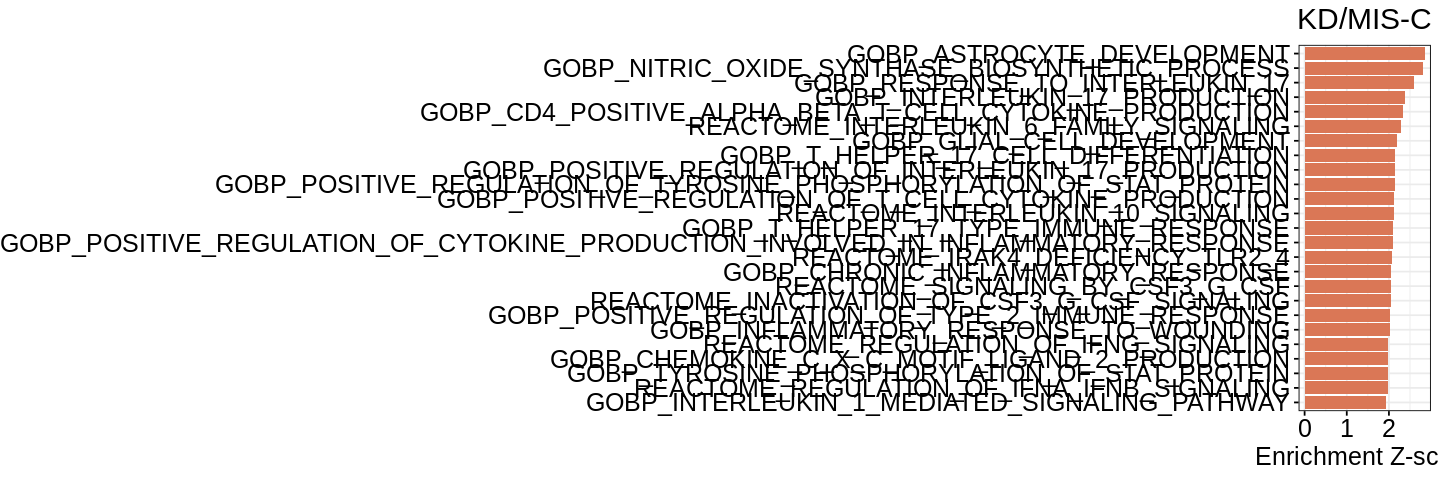

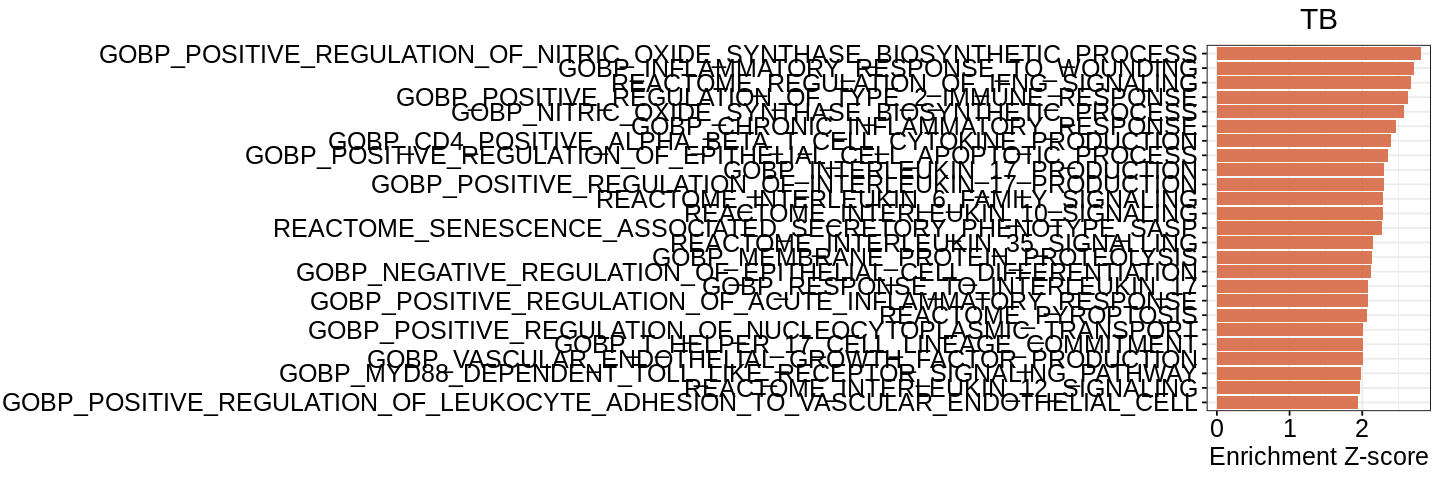

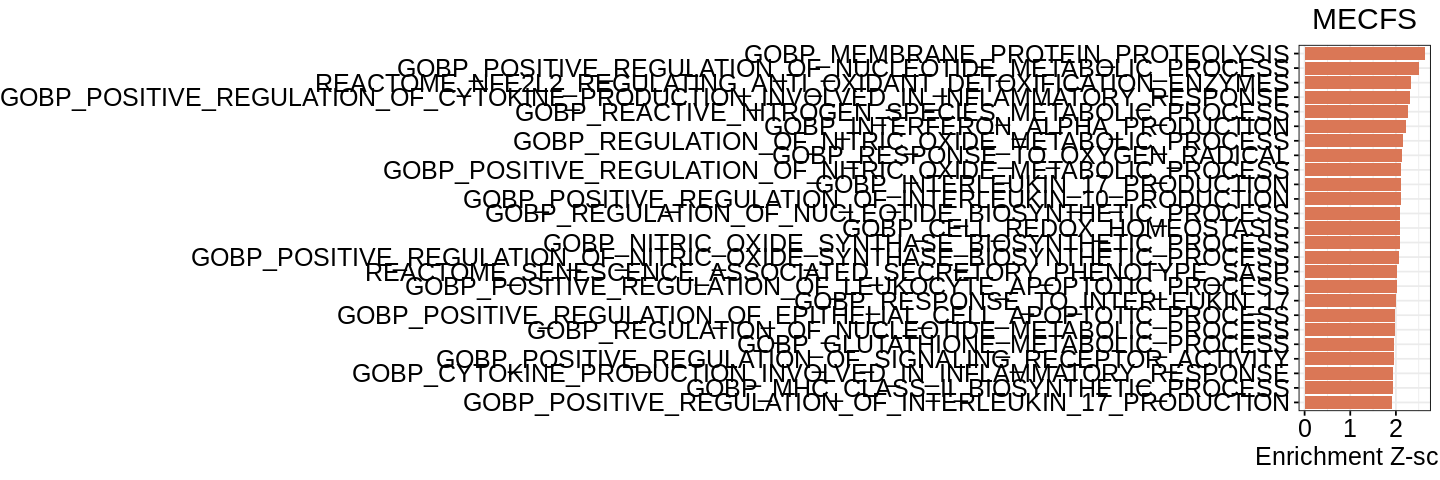

In [10]:
# Generate individual plots
p7 <- prepare_top10(ssgsea_kd_claude, "KD/MIS-C")
p8 <- prepare_top10(ssgsea_tb_claude, "TB")
p9 <- prepare_top10(ssgsea_mecfs_claude, "MECFS")

 options(repr.plot.height = 4, repr.plot.width = 12)

 ggplot(p7, aes(x = reorder(Pathway, Z), y = Z)) +
   geom_bar(stat = "identity", fill = "#DA7756") +
   coord_flip() +  # Horizontal bars
   labs(x = NULL, y = "Enrichment Z-score", title = "KD/MIS-C") +
   theme_cfrna_slides() +
   theme(legend.position = "none", plot.title = element_text(hjust = 0.5))

 ggplot(p8, aes(x = reorder(Pathway, Z), y = Z)) +
   geom_bar(stat = "identity", fill = "#DA7756") +
   coord_flip() +  # Horizontal bars
   labs(x = NULL, y = "Enrichment Z-score", title = "TB") +
   theme_cfrna_slides() +
   theme(legend.position = "none", plot.title = element_text(hjust = 0.5))

 ggplot(p9, aes(x = reorder(Pathway, Z), y = Z)) +
   geom_bar(stat = "identity", fill = "#DA7756") +
   coord_flip() +  # Horizontal bars
   labs(x = NULL, y = "Enrichment Z-score", title = "MECFS") +
   theme_cfrna_slides() +
   theme(legend.position = "none", plot.title = element_text(hjust = 0.5))

In [18]:
# Generate individual plots
p1 <- prepare_top10(ssgsea_kd_gpt, "KD/MIS-C")
p2 <- prepare_top10(ssgsea_tb_gpt, "TB")
p3 <- prepare_top10(ssgsea_mecfs_gpt, "MECFS")
p4 <- prepare_top10(ssgsea_kd_gemini, "KD/MIS-C")
p5 <- prepare_top10(ssgsea_tb_gemini, "TB")
p6 <- prepare_top10(ssgsea_mecfs_gemini, "MECFS")
p7 <- prepare_top10(ssgsea_kd_claude, "KD/MIS-C")
p8 <- prepare_top10(ssgsea_tb_claude, "TB")
p9 <- prepare_top10(ssgsea_mecfs_claude, "MECFS")

In [14]:
p3
p6
p9

Pathway,V2,Z
<chr>,<dbl>,<dbl>
REACTOME_INTERLEUKIN_35_SIGNALLING,1760.361,2.197535
GOBP_NITRIC_OXIDE_SYNTHASE_BIOSYNTHETIC_PROCESS,1750.405,2.171485
GOBP_RESPONSE_TO_DEXAMETHASONE,1740.180,2.144732
REACTOME_CRISTAE_FORMATION,1730.613,2.119699
REACTOME_FORMATION_OF_ATP_BY_CHEMIOSMOTIC_COUPLING,1730.613,2.119699
GOBP_NEGATIVE_REGULATION_OF_OXIDATIVE_STRESS_INDUCED_INTRINSIC_APOPTOTIC_SIGNALING_PATHWAY,1716.311,2.082278
GOBP_REGULATION_OF_OXIDATIVE_STRESS_INDUCED_INTRINSIC_APOPTOTIC_SIGNALING_PATHWAY,1715.968,2.081382
GOBP_MEMBRANE_PROTEIN_PROTEOLYSIS,1706.744,2.057247
REACTOME_PD_1_SIGNALING,1700.545,2.041027


Pathway,V2,Z
<chr>,<dbl>,<dbl>
GOBP_INTERFERON_ALPHA_PRODUCTION,617.6581,2.871380
REACTOME_SENESCENCE_ASSOCIATED_SECRETORY_PHENOTYPE_SASP,600.2696,2.706439
GOBP_POSITIVE_REGULATION_OF_INTERFERON_BETA_PRODUCTION,590.6491,2.615183
GOBP_POSITIVE_REGULATION_OF_CYTOKINE_PRODUCTION_INVOLVED_IN_INFLAMMATORY_RESPONSE,575.7046,2.473426
GOBP_NITRIC_OXIDE_SYNTHASE_BIOSYNTHETIC_PROCESS,571.6243,2.434722
GOBP_POSITIVE_REGULATION_OF_NITRIC_OXIDE_SYNTHASE_BIOSYNTHETIC_PROCESS,563.9361,2.361794
REACTOME_CELLULAR_SENESCENCE,556.5406,2.291643
REACTOME_INTERLEUKIN_10_SIGNALING,553.5193,2.262984
GOBP_INFLAMMATORY_RESPONSE_TO_WOUNDING,551.9291,2.247901


Pathway,V2,Z
<chr>,<dbl>,<dbl>
GOBP_MEMBRANE_PROTEIN_PROTEOLYSIS,376.8964,2.634332
GOBP_POSITIVE_REGULATION_OF_NUCLEOTIDE_METABOLIC_PROCESS,367.6092,2.516770
REACTOME_NFE2L2_REGULATING_ANTI_OXIDANT_DETOXIFICATION_ENZYMES,353.5165,2.338380
GOBP_POSITIVE_REGULATION_OF_CYTOKINE_PRODUCTION_INVOLVED_IN_INFLAMMATORY_RESPONSE,352.0415,2.319711
GOBP_REACTIVE_NITROGEN_SPECIES_METABOLIC_PROCESS,347.6435,2.264038
GOBP_INTERFERON_ALPHA_PRODUCTION,343.4671,2.211173
GOBP_REGULATION_OF_NITRIC_OXIDE_METABOLIC_PROCESS,338.3193,2.146010
GOBP_RESPONSE_TO_OXYGEN_RADICAL,336.9221,2.128325
GOBP_POSITIVE_REGULATION_OF_NITRIC_OXIDE_METABOLIC_PROCESS,335.9512,2.116034


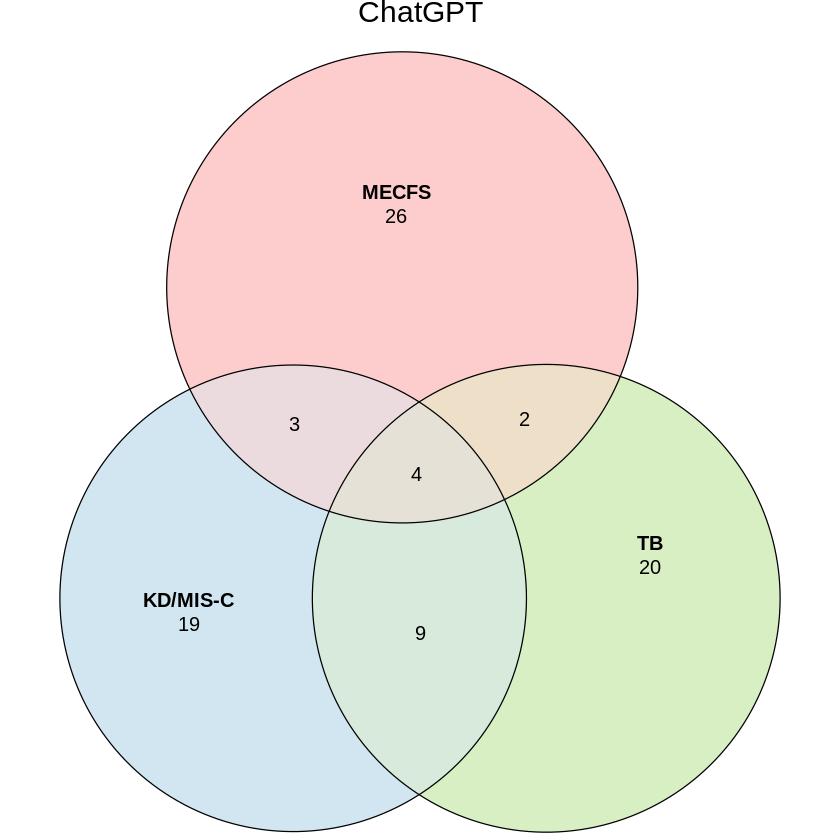

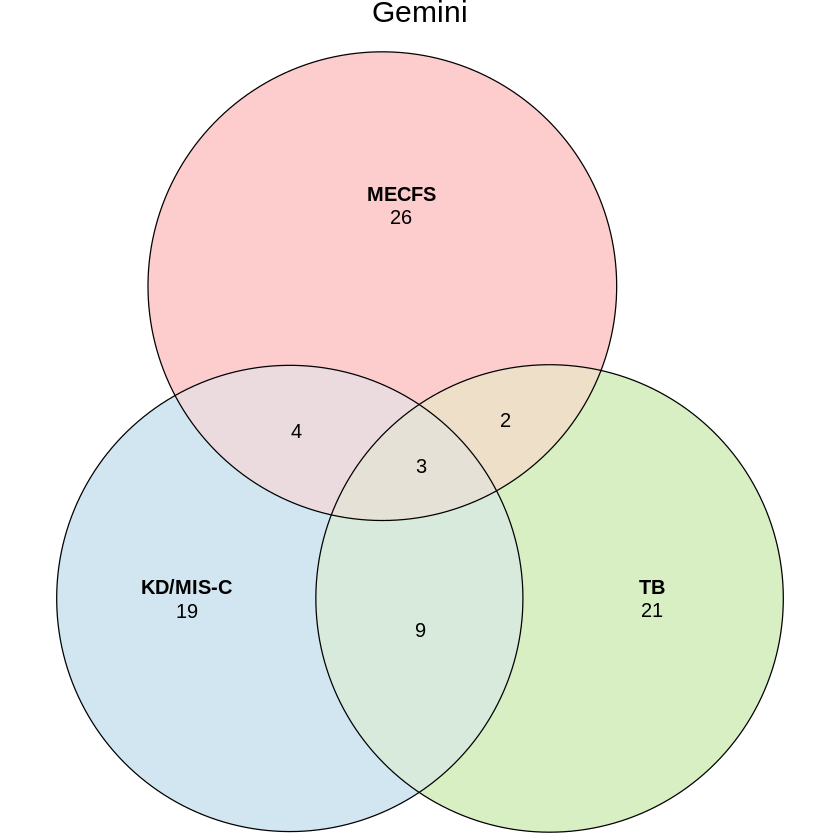

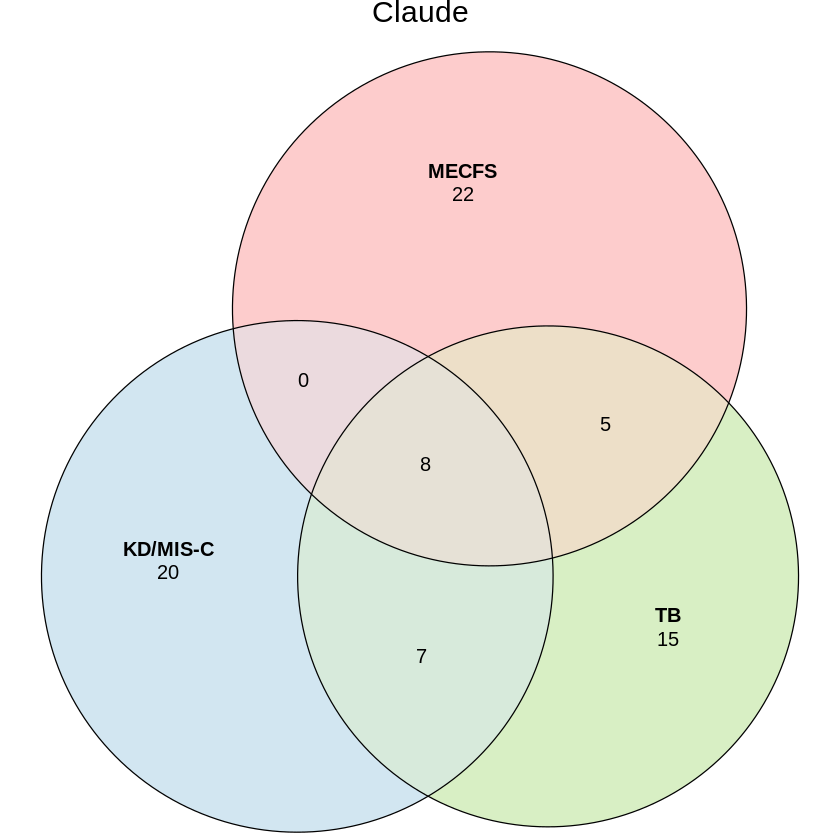

In [46]:
# If you haven’t already installed eulerr:
# install.packages("eulerr")

library(eulerr)

# 1) Define your three‐set pathway lists (using p1–p9)
sets <- list(
  ChatGPT = list(
    "KD/MIS-C" = p1$Pathway,
    "TB"       = p2$Pathway,
    "MECFS"    = p3$Pathway
  ),
  Gemini = list(
    "KD/MIS-C" = p4$Pathway,
    "TB"       = p5$Pathway,
    "MECFS"    = p6$Pathway
  ),
  Claude = list(
    "KD/MIS-C" = p7$Pathway,
    "TB"       = p8$Pathway,
    "MECFS"    = p9$Pathway
  )
)

# 2) Choose fill colors for the circles
cond_colors <- c(
  "KD/MIS-C" = "#A6CEE3",
  "TB"       = "#B2DF8A",
  "MECFS"    = "#FB9A99"
)

# 3) Loop over each model and save a PDF with proportional Venns
for(model_name in names(sets)) {
  eu <- euler(sets[[model_name]])
  
  # pdf(
  #   file   = sprintf("/workdir/adb258/ai_paper/figures/pathway_venn_%s.pdf", model_name),
  #   width  = 2.5,
  #   height = 2.5
  # )
  
  print(
    plot(eu,
         fills          = list(fill  = cond_colors[names(sets[[model_name]])],
                               alpha = 0.5),
         edges          = TRUE,
         quantities     = TRUE,
         labels         = names(sets[[model_name]]),
         main           = model_name,
         legend         = FALSE,
         # ↓↓↓ size tweaks ↓↓↓
         quantities.cex = 0.5,   # region counts at ~6-point
         labels.cex     = 0.5,   # category labels at ~6-point
         main.cex       = 0.67   # title at ~8-point
    )
  )
  
 # dev.off()
}

### Previous code below

In [19]:
# Helper to tag and return extracted data
extract_data <- function(p, dataset, model) {
  p %>%
    mutate(Dataset = dataset, Model = model)
}

# Apply to all 9 plots
df_all <- bind_rows(
  extract_data(p1, "KD/MIS-C",     "ChatGPT"),
  extract_data(p2, "TB",     "ChatGPT"),
  extract_data(p3, "MECFS",  "ChatGPT"),
  extract_data(p4, "KD/MIS-C",     "Gemini"),
  extract_data(p5, "TB",     "Gemini"),
  extract_data(p6, "MECFS",  "Gemini"),
  extract_data(p7, "KD/MIS-C",     "Claude"),
  extract_data(p8, "TB",     "Claude"),
  extract_data(p9, "MECFS",  "Claude")
)

df_all <- df_all %>%
  group_by(Pathway) %>%
  mutate(Appearance = n()) %>%
  ungroup()

# Indicator 1: Shared across models in same condition
shared_across_models <- df_all %>%
  distinct(Pathway, Dataset, Model) %>%
  group_by(Pathway, Dataset) %>%
  summarise(models_with_pathway = n(), .groups = "drop") %>%
  mutate(shared_across_models = models_with_pathway > 1) %>%
  dplyr::select(-models_with_pathway)

# Indicator 2: Shared across conditions in same model
shared_across_conditions <- df_all %>%
  distinct(Pathway, Model, Dataset) %>%
  group_by(Pathway, Model) %>%
  summarise(conditions_with_pathway = n(), .groups = "drop") %>%
  mutate(shared_across_conditions = conditions_with_pathway > 1) %>%
  dplyr::select(-conditions_with_pathway)

# Merge into df_all
df_all <- df_all %>%
  left_join(shared_across_models, by = c("Pathway", "Dataset")) %>%
  left_join(shared_across_conditions, by = c("Pathway", "Model"))

df_all <- df_all %>%
  mutate(
    Shape = ifelse(shared_across_models, 23, 21),       # 🔷 Diamond if shared across models
    StrokeWidth = ifelse(shared_across_conditions, 1.3, 0)  # 🞐 Stroke if shared across conditions
  )

df_all <- df_all %>% 
  mutate(
    Pathway = str_replace_all(                     # 2. underscores → spaces
                str_remove(Pathway, "^[^_]+_"),    # 1. drop prefix + “_”
                "_", " ")
  )

In [24]:
options(repr.plot.height = 8, repr.plot.width = 16)

pdf("/workdir/adb258/ai_paper/figures/pathway_overlaps.pdf", width = 8, height = 6)

ggplot(df_all, aes(x = Dataset, y = reorder(Pathway, Appearance))) +
  geom_point(aes(
    size = abs(Z),
    fill = Model,
    shape = as.factor(Shape),
    stroke = ifelse(shared_across_conditions, 0.75, 0)
  ),
  color = "black",  # <- always black outline
  show.legend = TRUE) +
  scale_size(range = c(2.5, 2.5)) +
  scale_fill_manual(values = c(
    "ChatGPT" = "#00A67E",
    "Gemini" = "#4796E3",
    "Claude" = "#DA7756"
  )) +
  scale_shape_manual(
    values = c("21" = 21, "23" = 23),
    labels = c("21" = "Unique / shared across models", "23" = "Shared across conditions"),
    name = "Condition Sharing"
  ) +
  labs(
    x = NULL,
    y = NULL,
    title = NULL,
    fill = "Model",
    size = "|Z Score|"
  ) +
  facet_grid(. ~ Model, scales = "free_x", space = "free_x") +
  theme_cfrna_print() +
  theme(
    panel.grid.major.y = element_blank(), 
    strip.text = element_text(size = 8, margin = margin(t = 2, r = 4, b = 2, l = 4))
  )

dev.off()

pdf 
  2